In [1]:
import os
import json
import builtins

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps, ImageDraw

from tqdm.notebook import tqdm

import pickle

from sklearn.model_selection import StratifiedKFold

import torch
from datasets import load_from_disk
from transformers import (
    SegformerForSemanticSegmentation,
    SegformerFeatureExtractor,
    logging,
)


Some functions are not fully parametrized, and they exist in separate modules.

Global variables would not work. Builtins are used instead for the variables that need to be passed to some functions.

The whole code needs to be completely parametrized to get rid of builtins.

In [2]:
# code_path = os.getcwd()

# the pretrained model used here
builtins.model_name = "mit-b4"
builtins.model_name_full = "nvidia/" + model_name
# the input image size for the pretrained model
builtins.image_size = (512, 512)
# choose batch size based on memory requirements for the model
builtins.model_batch_size = 6
# number of epochs used for training
num_epochs = 100

"""
# the pretrained model used here
builtins.model_name = "mit-b3"
builtins.model_name_full = "nvidia/" + model_name
# the input image size for the pretrained model
builtins.image_size = (512, 512)
# choose batch size based on memory requirements for the model
builtins.model_batch_size = 8
# number of epochs used for training
num_epochs = 100
"""

# folder containing the main dataset in HuggingFace format
train_dataset_path = "bus_4in1_datasets_single_class_" + str(image_size[0])

# folder containing all baseline model artifacts
baseline_dir = "model_baseline_" + model_name

model_dir = baseline_dir + "/models"
output_dir = baseline_dir + "/outputs"
logging_dir = baseline_dir + "/logs"
folds_dir = baseline_dir + "/folds"

# Where the various original datasets are located
if os.uname()[1] == "media":
    # Florin's gaming PC
    data_volume = "/home/florin/data"
else:
    # Google Colab
    from google.colab import drive

    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path, force_remount=False)
    data_volume = gdrive_path + "/MyDrive"


# Create the dataframe for the main dataset

Concatenates lists of images from 4 different datasets.

Contains image file paths, original dataset indicator, and other attributes, for all images.

In [3]:
# project library - datasets and dataloaders
from bus_data import (
    labels_ids_bus,
    busis_dataset_make,
    bus_dataset_b_make,
    dataset_busi_with_gt_make,
    mayo_dataset_make,
)


train_df = pd.DataFrame(
    {
        "dataset": [],
        "image": [],
        "mask": [],
        "tumor": [],
    }
)

train_df = pd.concat([train_df, busis_dataset_make(data_volume)], ignore_index=True)
train_df = pd.concat([train_df, bus_dataset_b_make(data_volume)], ignore_index=True)
train_df = pd.concat(
    [train_df, dataset_busi_with_gt_make(data_volume)], ignore_index=True
)
train_df = pd.concat([train_df, mayo_dataset_make(data_volume)], ignore_index=True)

# convert Path to string, HuggingFace wants strings here
train_df["image"] = train_df["image"].apply(lambda x: str(x))
train_df["mask"] = train_df["mask"].apply(lambda x: [str(xi) for xi in x])
train_df["dataset_tumor"] = train_df["dataset"] + "_" + train_df["tumor"]

builtins.train_df = train_df

train_df


,dataset,image,mask,tumor,dataset_tumor
0,BUSIS,/home/florin/data/BUS Project Home/Datasets/BUSIS/Original/case104.png,[/home/florin/data/BUS Project Home/Datasets/BUSIS/GT/case104_GT.bmp],benign,BUSIS_benign
1,BUSIS,/home/florin/data/BUS Project Home/Datasets/BUSIS/Original/case325.png,[/home/florin/data/BUS Project Home/Datasets/BUSIS/GT/case325_GT.bmp],malignant,BUSIS_malignant
2,BUSIS,/home/florin/data/BUS Project Home/Datasets/BUSIS/Original/case425.png,[/home/florin/data/BUS Project Home/Datasets/BUSIS/GT/case425_GT.bmp],malignant,BUSIS_malignant
3,BUSIS,/home/florin/data/BUS Project Home/Datasets/BUSIS/Original/case339.png,[/home/florin/data/BUS Project Home/Datasets/BUSIS/GT/case339_GT.bmp],benign,BUSIS_benign
4,BUSIS,/home/florin/data/BUS Project Home/Datasets/BUSIS/Original/case216.png,[/home/florin/data/BUS Project Home/Datasets/BUSIS/GT/case216_GT.bmp],malignant,BUSIS_malignant
...,...,...,...,...,...
1789,Mayo,/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/761858134_long.png,[/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/761858134_long_mask.png],benign,Mayo_benign
1790,Mayo,/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/679670173_long.png,[/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/679670173_long_mask.png],malignant,Mayo_malignant
1791,Mayo,/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/805361134_tran.png,[/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/805361134_tran_mask.png],benign,Mayo_benign
1792,Mayo,/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/451084310_dopp.png,[/home/florin/data/BUS Project Home/Datasets/Mayo/mayo_dataset/451084310_dopp_mask.png],benign,Mayo_benign


# Create and/or load the main dataset

It uses the HuggingFace DS format.

In [4]:
# mapping classes to/from pixel values
builtins.id2label, builtins.label2id, builtins.num_labels = labels_ids_bus(
    multiclass=False
)

id2label


{0: 'unlabeled', 1: 'lesion'}

The first time you run the next cell, you will need a lot of memory:
32 GB RAM + 32 GB swap should work.

Once the DS is created, on subsequent runs the memory requirements will be much lower.

In [5]:
from create_load_dataset import create_hf_train_dataset

# If HuggingFace dataset exists, load it.
# Otherwise create and save it.
if os.path.isdir(train_dataset_path):
    ds_hf = load_from_disk(train_dataset_path)
else:
    ds_hf = create_hf_train_dataset(train_df)
    ds_hf.save_to_disk(train_dataset_path)


Test the main HF dataset.

{'dataset': 0,
 'pixel_values': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'tumor': 1,
 'dataset_tumor': 1,
 'index': 10,
 'original_image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=512x512>,
 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=512x512>}

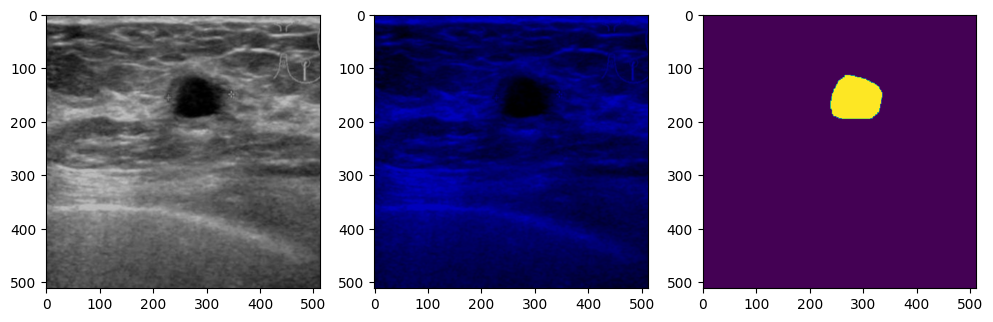

In [6]:
i = 10
display(ds_hf[i])
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
ax[0].imshow(ds_hf[i]["original_image"])
ax[1].imshow(ds_hf[i]["pixel_values"])
ax[2].imshow(ds_hf[i]["label"])
plt.show()


# Augmentations and feature extraction

Load the transform functions used for image augmentation.

In [7]:
# the workhorse of feature extraction
# image transforms are built around it
builtins.feature_extractor = SegformerFeatureExtractor(
    do_normalize=True
).from_pretrained(builtins.model_name_full)

from train_val_transforms import train_transforms, val_transforms, val_transforms_check


Test the functions.

`train_transforms()` should generate a different output every time you run the next cell.

The other two transforms should stay the same.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


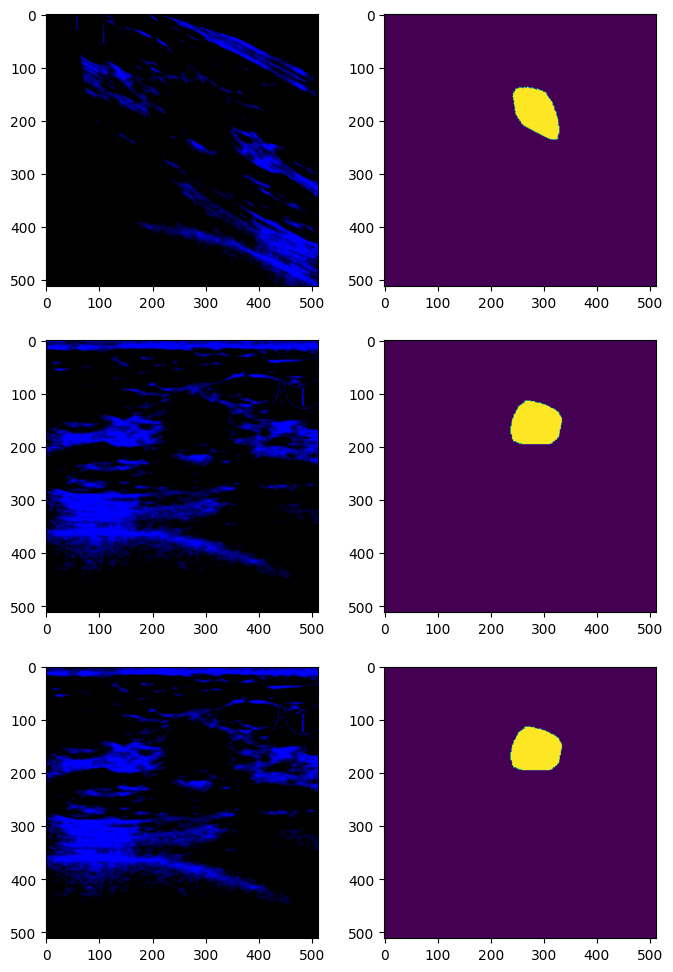

In [8]:
# passing control variables to transform functions
builtins.APPLY_CLICKS_TRAIN_DS = False
builtins.APPLY_CLICKS_TEST_DS = False

i = 10
tt_out = train_transforms(ds_hf[i : i + 1])
vt_out = val_transforms(ds_hf[i : i + 1])
vtc_out = val_transforms_check(ds_hf[i : i + 1])

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(8, 12))
ax[0, 0].imshow(np.moveaxis(tt_out["pixel_values"][0], 0, -1))
ax[0, 1].imshow(tt_out["labels"][0])
ax[1, 0].imshow(np.moveaxis(vt_out["pixel_values"][0], 0, -1))
ax[1, 1].imshow(vt_out["labels"][0])
ax[2, 0].imshow(np.moveaxis(vtc_out["pixel_values"][0], 0, -1))
ax[2, 1].imshow(vtc_out["labels"][0])
plt.show()


# Load pretrained model, fine tune it on labeled datasets

Split the main dataset in 5 folds. Train 5 baseline models using the 5-fold split. Save each model.

Generate and save predictions for each baseline model. Collect performance metrics for each model.

This way, we can generate predictions for each image in the main dataset.

In [9]:
from model_functions import objective, generate_predictions


In [10]:
os.makedirs(model_dir, exist_ok=True)
os.makedirs(logging_dir, exist_ok=True)
os.makedirs(folds_dir, exist_ok=True)

predictions_path = baseline_dir + "/predictions"

# baseline models do not use clicks for training
builtins.APPLY_CLICKS_TRAIN_DS = False
builtins.APPLY_CLICKS_TEST_DS = False

if os.path.exists(predictions_path):
    RUN_BASELINE_PREDICTIONS = False
else:
    RUN_BASELINE_PREDICTIONS = True

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
fold = 0
performance_metrics = {}
fold_metrics_training = {}
for train_index, test_index in skf.split(
    train_df.index.to_list(), train_df["dataset_tumor"]
):
    # shuffle the train order to mix all datasets together
    # test order doesn't matter
    rng = np.random.default_rng(seed=1)
    rng.shuffle(train_index)

    fold += 1
    print("\n###################################################")
    print(f"fold {fold}")
    train_ds = ds_hf.select(train_index)
    # the model only accepts certain columns in the test_ds while training
    # so we create two test_ds datasets
    # this is for the model training, only has image and label
    test_ds = ds_hf.select(test_index)
    # this is for generating predictions with a trained model, and has all image attributes
    test_ds_check = ds_hf.select(test_index)

    train_ds.set_transform(train_transforms)
    test_ds.set_transform(val_transforms)
    test_ds_check.set_transform(val_transforms_check)

    if not os.path.exists(model_dir + "/fold-" + str(fold).zfill(10)):
        print("model does not exist, train it")
        fold_metrics_training[fold] = objective(
            fold=fold,
            train_ds=train_ds,
            test_ds=test_ds,
            model_dir=model_dir,
            logging_dir=logging_dir,
            output_dir=output_dir,
            folds_dir=folds_dir,
            epochs=num_epochs,
        )
        print()
        print(
            "mean performance per fold, from total pixel counts across the entire fold, measured during training:"
        )
        print(pd.DataFrame(fold_metrics_training[fold], index=["values"]).T)
    else:
        print("model exists, do not train it")

    if RUN_BASELINE_PREDICTIONS:
        print("load trained model to evaluate performance")
        best_model_dir = model_dir + "/fold-" + str(fold).zfill(10)
        logging.set_verbosity(50)
        model = SegformerForSemanticSegmentation.from_pretrained(
            best_model_dir, id2label=id2label, label2id=label2id, num_labels=num_labels
        )
        model.to("cuda:0")
        logging.set_verbosity(40)

        performance_metrics_fold = generate_predictions(
            model=model, test_ds=test_ds_check, pr_path=predictions_path
        )
        for k, v in performance_metrics_fold.items():
            performance_metrics[k] = v

        del model
        torch.cuda.empty_cache()

if len(fold_metrics_training.keys()) == 5:
    with open(baseline_dir + "/fold_metrics_training.json", "w") as pfile:
        json.dump(fold_metrics_training, pfile, indent=2)

if RUN_BASELINE_PREDICTIONS:
    with open(predictions_path + ".json", "w") as pfile:
        json.dump(performance_metrics, pfile, indent=2)



###################################################
fold 1
model does not exist, train it

mean performance per fold, from total pixel counts across the entire fold, measured during training:
                     values
best_iou           0.755363
best_dice          0.860635
best_precision     0.893093
best_recall        0.830453
best_step       4940.000000
best_loss          0.061859
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/359 [00:00<?, ?it/s]

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_positives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277: RuntimeWarning: invalid value encountered in divide
  niou = total_true_positives / (
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:281: RuntimeWarning: invalid value encountered in divide
  2
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_a


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.818432
iou        0.747466
precision  0.851385
recall     0.823394

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.860627
iou        0.755351
precision  0.893092
recall     0.830439

###################################################
fold 2
model does not exist, train it

mean performance per fold, from total pixel counts across the entire fold, measured during training:
                     values
best_iou           0.740658
best_dice          0.851009
best_precision     0.904431
best_recall        0.803546
best_step       5360.000000
best_loss          0.058773
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/359 [00:00<?, ?it/s]

...

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_positives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277: RuntimeWarning: invalid value encountered in divide
  niou = total_true_positives / (
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:281: RuntimeWarning: invalid value encountered in divide
  2
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_a


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.857159
iou        0.786303
precision  0.864841
recall     0.875370

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.885437
iou        0.794426
precision  0.878599
recall     0.892383

###################################################
fold 5
model does not exist, train it

mean performance per fold, from total pixel counts across the entire fold, measured during training:
                     values
best_iou           0.785881
best_dice          0.880105
best_precision     0.926438
best_recall        0.838185
best_step       4400.000000
best_loss          0.056362
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/358 [00:00<?, ?it/s]

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_positives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_area_label
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:287: RuntimeWarning: invalid value encountered in divide
  recall = total_true_positives / (total_true_positives + total_false_negatives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277:


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.845151
iou        0.778164
precision  0.885095
recall     0.839597

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.880107
iou        0.785886
precision  0.926441
recall     0.838187


Dataframe with performance metrics of predictions for each image.

In [11]:
with open(predictions_path + ".json", "r") as pfile:
    performance_metrics = json.load(pfile)
    performance_metrics = {int(k): v for k, v in performance_metrics.items()}

image_perf_df = train_df[["dataset", "tumor", "dataset_tumor"]].copy()
image_perf_df["iou"] = [
    performance_metrics[x]["per_category_niou"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df["dice"] = [
    performance_metrics[x]["per_category_dice"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df["precision"] = [
    performance_metrics[x]["per_category_precision"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df["recall"] = [
    performance_metrics[x]["per_category_recall"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df["area_label"] = [
    performance_metrics[x]["total_area_label"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df["area_pred"] = [
    performance_metrics[x]["total_area_pred"][1]
    for x in range(len(performance_metrics.keys()))
]
image_perf_df.to_csv(baseline_dir + "/image_perf_df.csv")
image_perf_df


,dataset,tumor,dataset_tumor,iou,dice,precision,recall,area_label,area_pred
0,BUSIS,benign,BUSIS_benign,0.934169,0.965964,0.944324,0.988619,38310.0,40107.0
1,BUSIS,malignant,BUSIS_malignant,0.874360,0.932969,0.882431,0.989648,60954.0,68360.0
2,BUSIS,malignant,BUSIS_malignant,0.818906,0.900438,0.893830,0.907144,17791.0,18056.0
3,BUSIS,benign,BUSIS_benign,0.940002,0.969073,0.987825,0.951020,20988.0,20206.0
4,BUSIS,malignant,BUSIS_malignant,0.921937,0.959383,0.956739,0.962042,62780.0,63128.0
...,...,...,...,...,...,...,...,...,...
1789,Mayo,benign,Mayo_benign,0.825369,0.904331,0.938487,0.872574,9739.0,9055.0
1790,Mayo,malignant,Mayo_malignant,0.585480,0.738552,0.996810,0.586579,4262.0,2508.0
1791,Mayo,benign,Mayo_benign,0.798531,0.887981,0.818720,0.970045,1569.0,1859.0
1792,Mayo,benign,Mayo_benign,0.824832,0.904009,0.914378,0.893872,3166.0,3095.0


# Generate true positives, false positives, false negatives from predictions

For each image, use its mask prediction and extract TP, FP, FN areas. Split each area into contiguous segments. Save all segments as NumPy arrays.

If multiprocessing is used in the code, and then dataloaders are invoked later,

the dataloaders may break. The problem is either in PyTorch or in the Transformers library.

We've moved multiprocessing to separate scripts wherever it occurs.

In [12]:
! python3 ./make_segments.py {baseline_dir} {train_dataset_path} {predictions_path}


100%|███████████████████████████████████████████| 15/15 [00:13<00:00,  1.15it/s]


Dataframe with attributes of TP, FP, FN segments

In [13]:
segment_stats = pd.read_csv(baseline_dir + "/segment_stats.csv", index_col=0)
segment_stats


,image_index,iou,segment_index,segment_type,segment_size
0,0,0.934169,1,false_positives,2
1,0,0.934169,2,false_positives,4
2,0,0.934169,3,false_positives,196
3,0,0.934169,4,false_positives,141
4,0,0.934169,5,false_positives,1
...,...,...,...,...,...
28037,1793,0.733978,5,false_positives,29
28038,1793,0.733978,1,false_negatives,518
28039,1793,0.733978,2,false_negatives,39
28040,1793,0.733978,3,false_negatives,29


# Generate clicks from TP, FP, FN segments

Use Voronoi tiling, via simulated annealing, to generate positive and negative clicks filling some of the TP, FP, FN segments.

Only big-enough segments generate clicks.

Only images with IoU below some threshold will have clicks.

There is a maximum budget of clicks per image, to prevent click spam.

Save click coordinates.

Also save the output ("energy") from simulated annealing, for troubleshooting.

In [14]:
! python3 ./uniform_clicks.py {baseline_dir}


100%|██████████████████████████████████████████| 15/15 [35:15<00:00, 141.01s/it]


Click coordinates generated from segments

True positives are counted separately - positive clicks are generated separately for true and for false positives.

In [15]:
with open(baseline_dir + "/guide_clicks.json", "r") as gcfile:
    guide_clicks = json.load(gcfile)
    guide_clicks = {int(k): v for k, v in guide_clicks.items()}

i = 0
for k, v in guide_clicks.items():
    i += 1
    print(k, v)
    if i > 5:
        break


0 {'clicks_positive_tp': [[239, 223], [230, 344], [185, 399], [169, 272]], 'clicks_negative': [[193, 178]], 'clicks_positive': []}
1 {'clicks_positive_tp': [[118, 391], [110, 322], [229, 390], [177, 228]], 'clicks_negative': [[224, 188], [259, 201], [252, 500], [293, 483]], 'clicks_positive': []}
2 {'clicks_positive_tp': [[340, 271], [224, 298], [277, 266]], 'clicks_negative': [[188, 253]], 'clicks_positive': [[290, 320]]}
3 {'clicks_positive_tp': [], 'clicks_negative': [], 'clicks_positive': []}
4 {'clicks_positive_tp': [], 'clicks_negative': [], 'clicks_positive': []}
5 {'clicks_positive_tp': [[225, 328], [170, 270], [138, 332]], 'clicks_negative': [], 'clicks_positive': [[228, 395]]}


# Sample a few images, segments, and clicks

## Segment colors

white = TP

green = FP

red = FN

yellow = original mask (label)

## Click colors

green = activating clicks

red = inhibitory clicks

  0%|          | 0/6 [00:00<?, ?it/s]

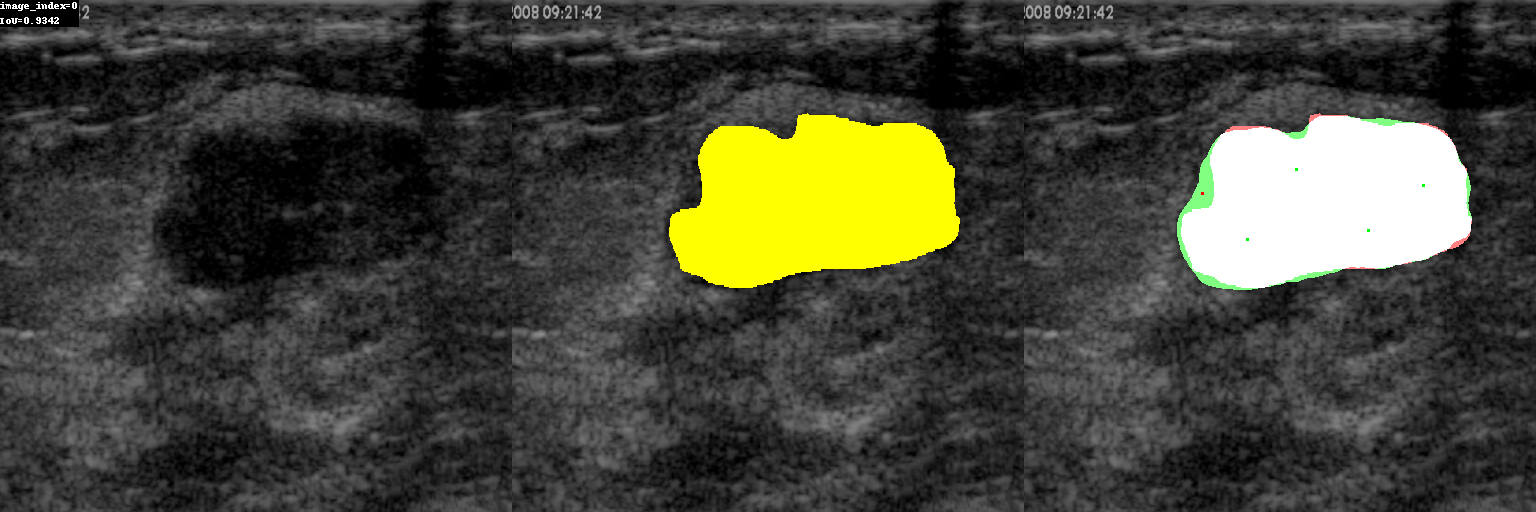

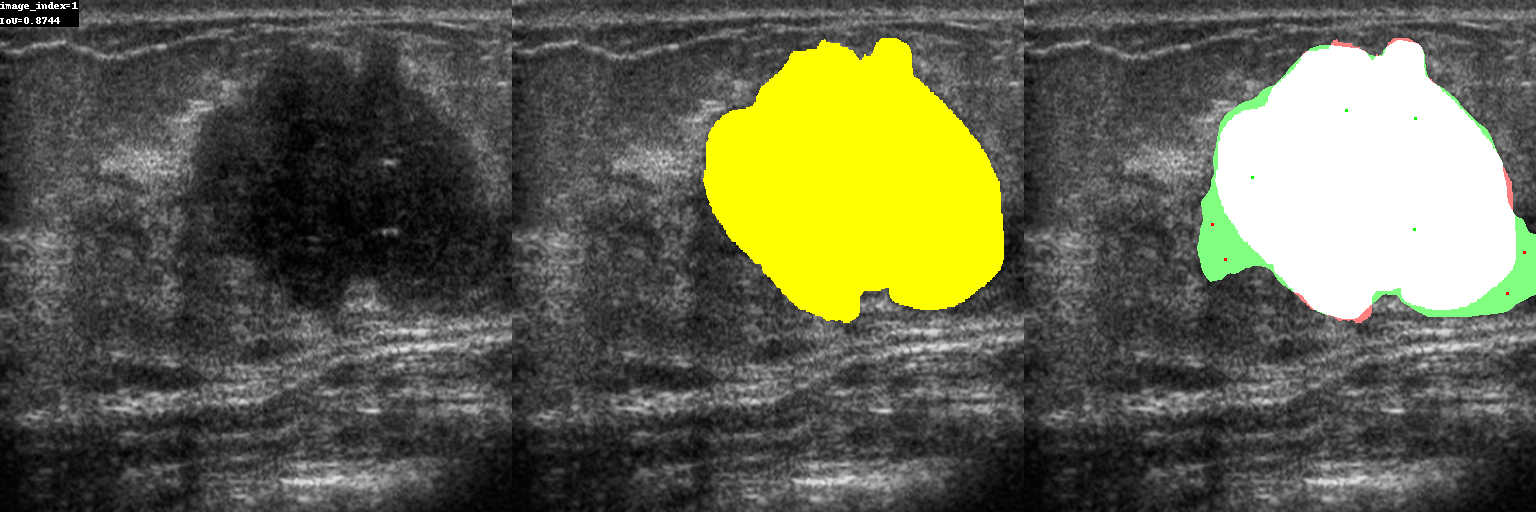

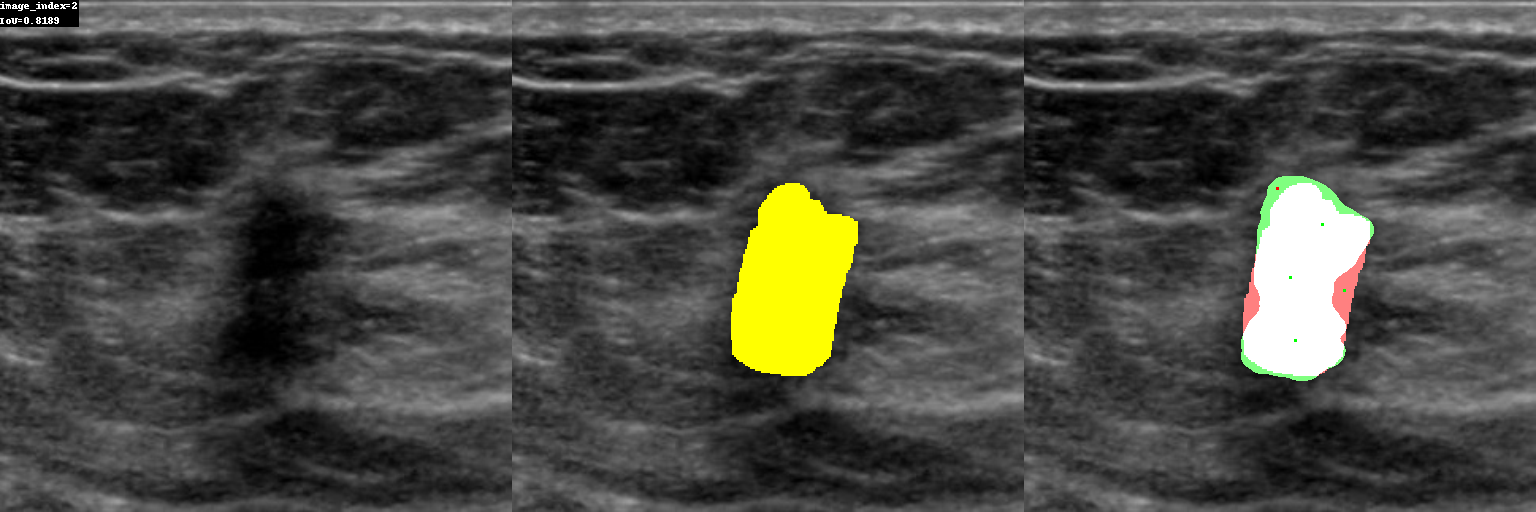

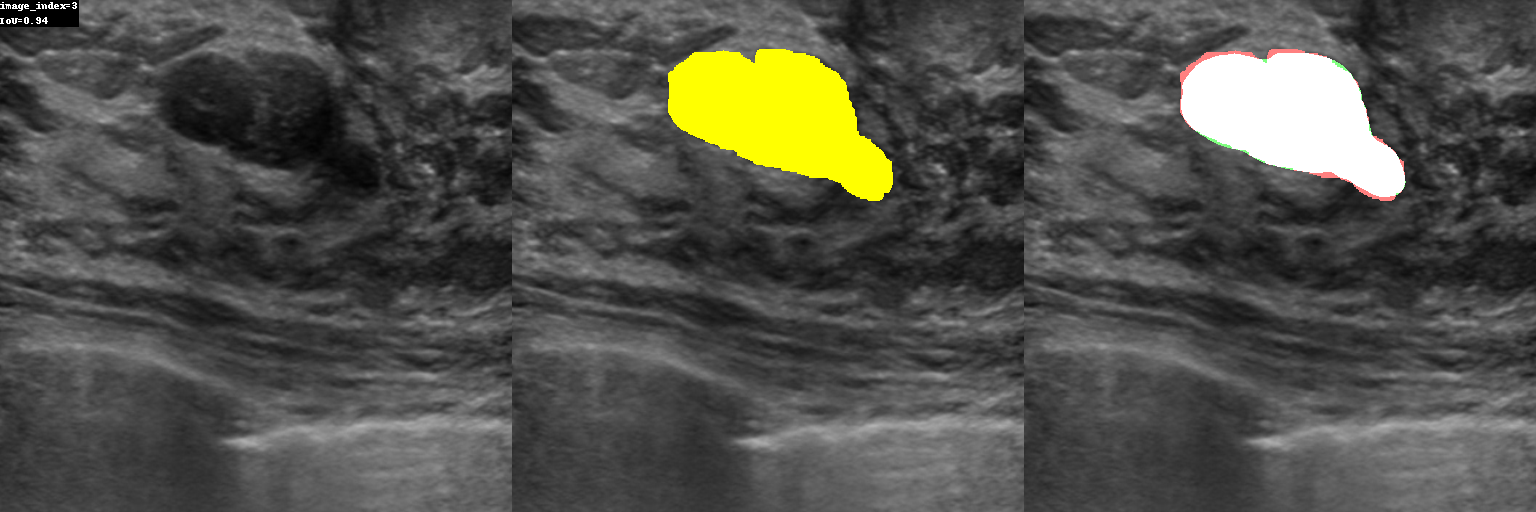

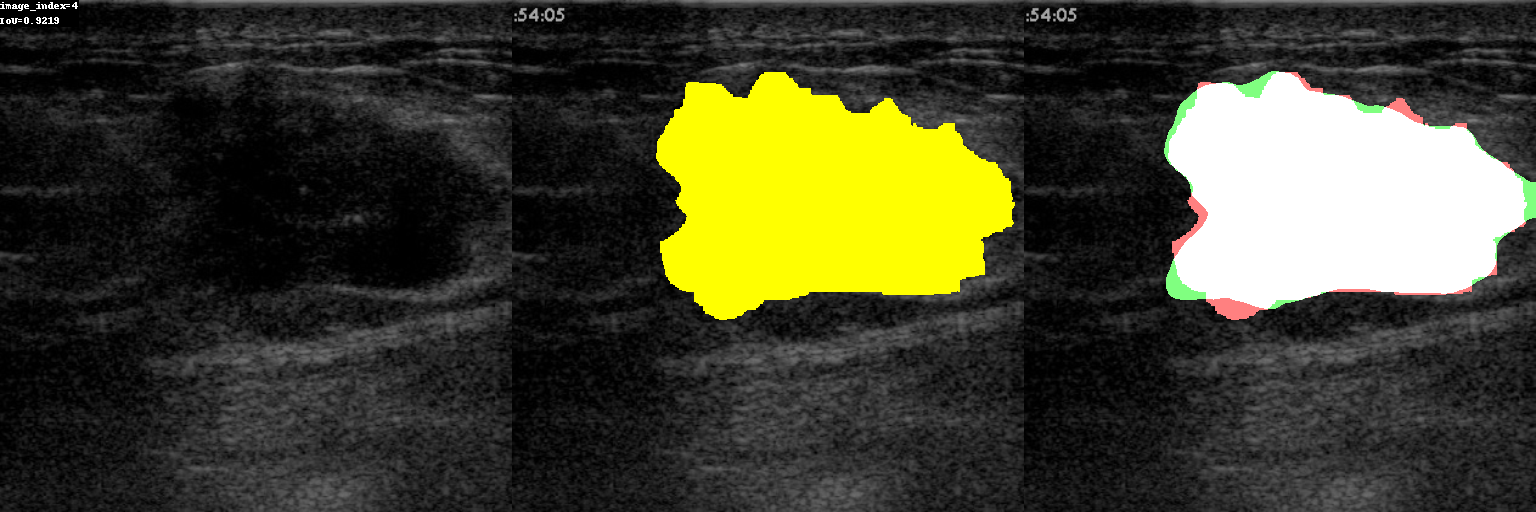

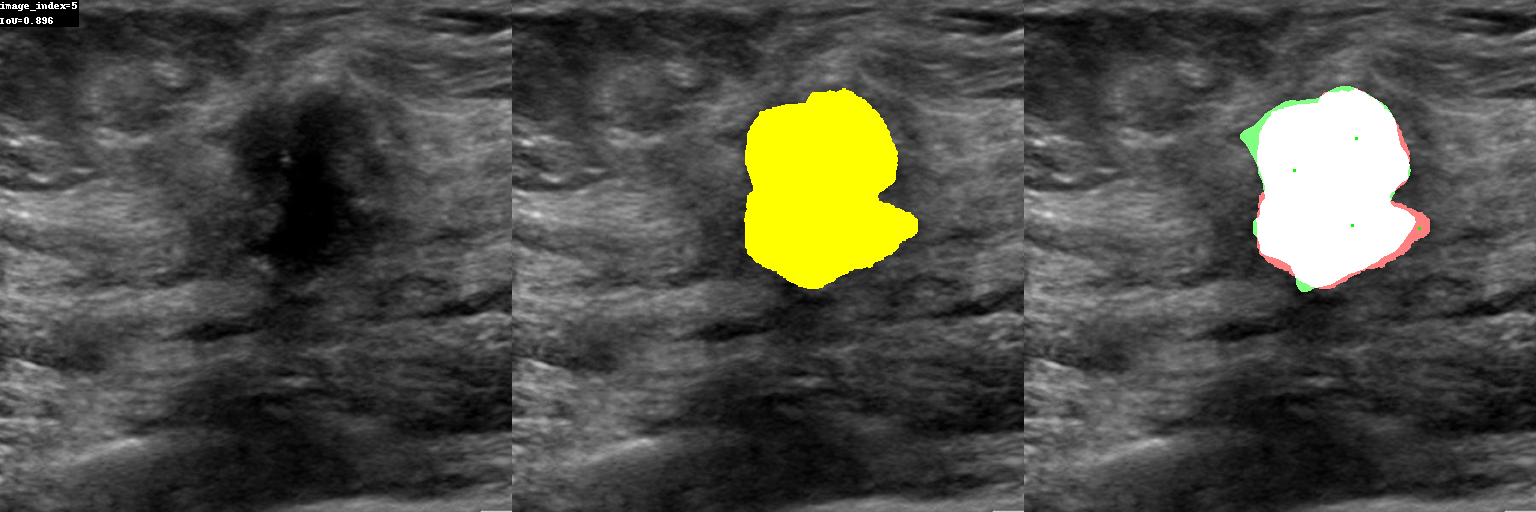

In [16]:
s_color = {
    "true_positives": [255, 255, 255],
    "false_positives": [128, 255, 128],
    "false_negatives": [255, 128, 128],
}

segment_files = baseline_dir + "/segment_files"

for i in tqdm(range(0, 6)):
    original_image = ds_hf[i]["original_image"]

    image_stats = segment_stats[segment_stats["image_index"] == i]
    clicks = guide_clicks[i]

    label_arr = np.array(ds_hf[i]["label"], dtype=np.uint8) * 255
    label_img = ImageOps.colorize(
        Image.fromarray(label_arr, mode="L"),
        black=[0, 0, 0],
        white=[255, 255, 0],
        blackpoint=0,
        whitepoint=255,
    )
    img_label_merged = Image.composite(
        label_img, original_image, Image.fromarray(label_arr, mode="L")
    )

    s_merged = original_image
    for st in s_color.keys():
        st_stats = image_stats[image_stats["segment_type"] == st]
        for s in st_stats.iterrows():
            with open(
                segment_files
                + "/"
                + str(i)
                + "/"
                + st
                + "/"
                + str(s[1]["segment_index"])
                + ".pkl",
                "rb",
            ) as s_file:
                s_arr = pickle.load(s_file)
                s_arr = s_arr * 255
                s_img = ImageOps.colorize(
                    Image.fromarray(s_arr, mode="L"),
                    black=[0, 0, 0],
                    white=s_color[st],
                    blackpoint=0,
                    whitepoint=255,
                )
                s_merged = Image.composite(
                    s_img, s_merged, Image.fromarray(s_arr, mode="L")
                )

    for c in clicks["clicks_positive_tp"]:
        # Pillow and Numpy disagree on the meaning of X and Y
        # we use the Numpy convention
        # so for Pillow we swap X and Y
        ImageDraw.Draw(s_merged).rectangle(
            xy=[(c[1] - 1, c[0] - 1), (c[1] + 1, c[0] + 1)],
            outline=(0, 255, 0),
            fill=(0, 255, 0),
            width=1,
        )

    for c in clicks["clicks_positive"]:
        # Pillow and Numpy disagree on the meaning of X and Y
        # we use the Numpy convention
        # so for Pillow we swap X and Y
        ImageDraw.Draw(s_merged).rectangle(
            xy=[(c[1] - 1, c[0] - 1), (c[1] + 1, c[0] + 1)],
            outline=(0, 255, 0),
            fill=(0, 255, 0),
            width=1,
        )

    for c in clicks["clicks_negative"]:
        # Pillow and Numpy disagree on the meaning of X and Y
        # we use the Numpy convention
        # so for Pillow we swap X and Y
        ImageDraw.Draw(s_merged).rectangle(
            xy=[(c[1] - 1, c[0] - 1), (c[1] + 1, c[0] + 1)],
            outline=(255, 0, 0),
            fill=(255, 0, 0),
            width=1,
        )

    oi_text = "image_index=" + str(i)
    oi_text += "\n" + "IoU=" + str(round(image_perf_df.loc[i, "iou"], ndigits=4))
    draw = ImageDraw.Draw(original_image)
    bbox = draw.multiline_textbbox((0, 0), oi_text)
    draw.rectangle(bbox, fill="black")
    draw.text((0, 0), oi_text)

    big_frame = Image.new(
        mode="RGB",
        size=(builtins.image_size[0] * 3, builtins.image_size[0]),
        color=(0, 0, 0),
    )
    big_frame.paste(original_image, box=(0, 0))
    big_frame.paste(img_label_merged, box=(builtins.image_size[0], 0))
    big_frame.paste(s_merged, box=(builtins.image_size[0] * 2, 0))
    display(big_frame)


# Check the energy maps for a few segments

The outputs from simulated annealing for each segment that has generated clicks. The outputs are heat maps showing the "energy" optimized by simulated annealing.

This is to make sure the click generator works properly.

If no clicks were generated for a type of segments, the energy map is empty.

image index: 0


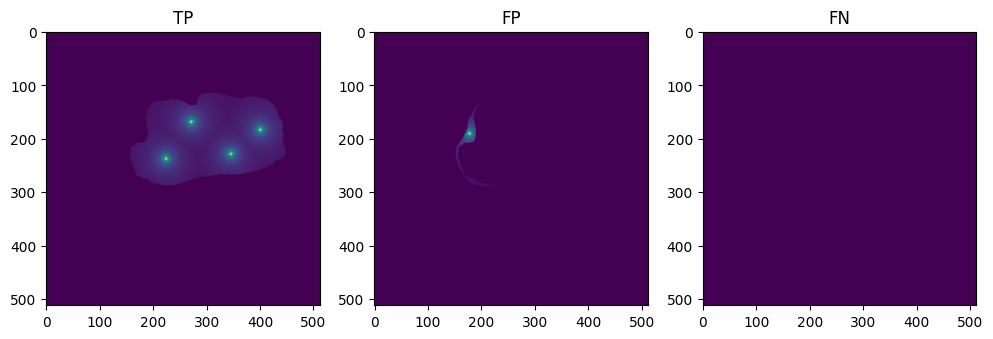

image index: 1


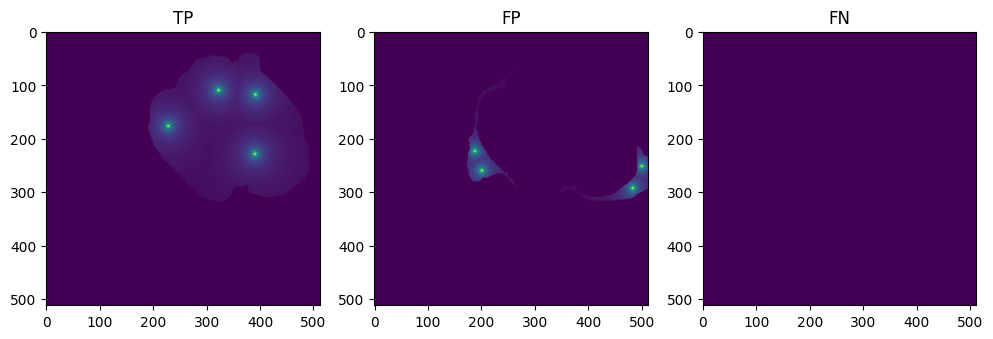

image index: 2


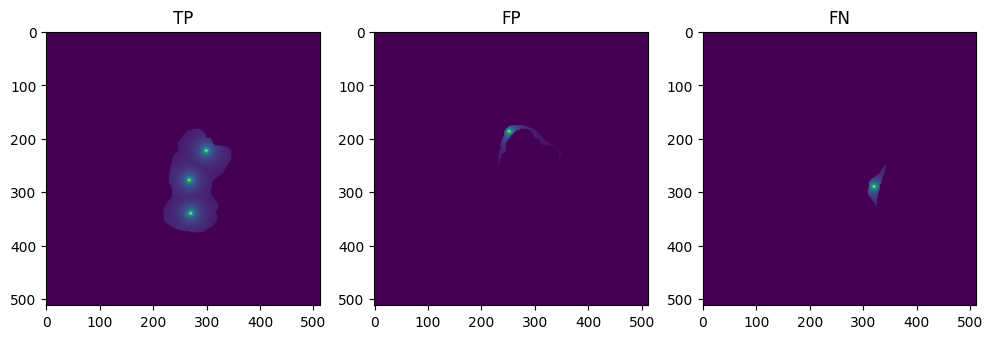

image index: 3


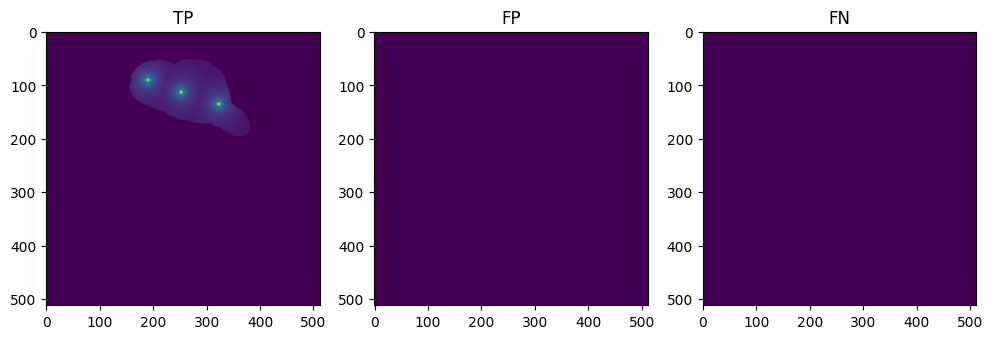

image index: 4


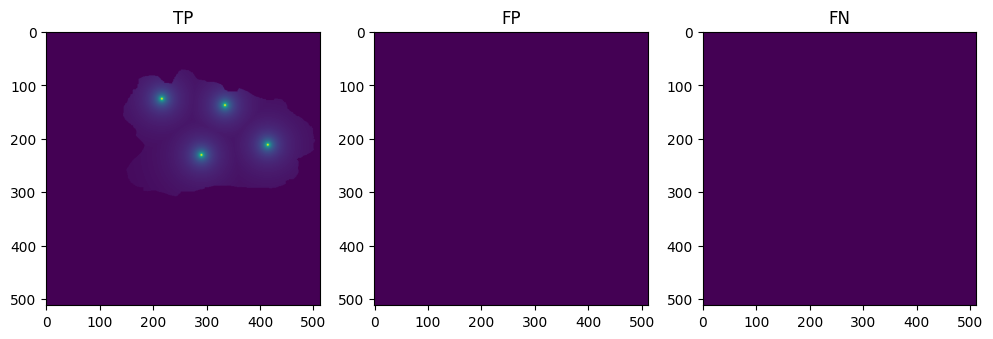

image index: 5


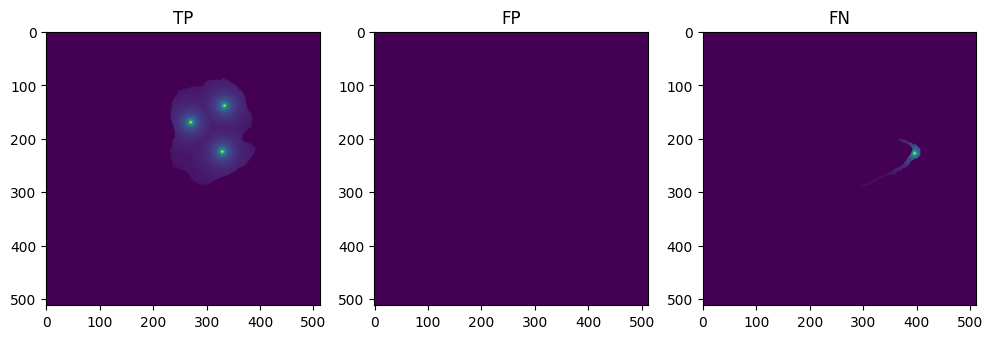

In [17]:
for i in range(0, 6):
    print("image index:", i)
    seg_dir = baseline_dir + "/energy/" + str(i) + "/true_positives"
    tp_arr = np.zeros(builtins.image_size, dtype=np.float64)
    if os.path.exists(seg_dir):
        for f in os.listdir(seg_dir):
            with open(seg_dir + "/" + f, "rb") as arr_file:
                tp_arr += pickle.load(arr_file)
    seg_dir = baseline_dir + "/energy/" + str(i) + "/false_positives"
    fp_arr = np.zeros(builtins.image_size, dtype=np.float64)
    if os.path.exists(seg_dir):
        for f in os.listdir(seg_dir):
            with open(seg_dir + "/" + f, "rb") as arr_file:
                fp_arr += pickle.load(arr_file)
    seg_dir = baseline_dir + "/energy/" + str(i) + "/false_negatives"
    fn_arr = np.zeros(builtins.image_size, dtype=np.float64)
    if os.path.exists(seg_dir):
        for f in os.listdir(seg_dir):
            with open(seg_dir + "/" + f, "rb") as arr_file:
                fn_arr += pickle.load(arr_file)
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3.8))
    ax[0].set_title("TP")
    ax[1].set_title("FP")
    ax[2].set_title("FN")
    ax[0].imshow(np.log10(tp_arr + 0.1))
    ax[1].imshow(np.log10(fp_arr + 0.1))
    ax[2].imshow(np.log10(fn_arr + 0.1))
    plt.show()


# Segment stats

Stats for the TP, FP, FN segments.

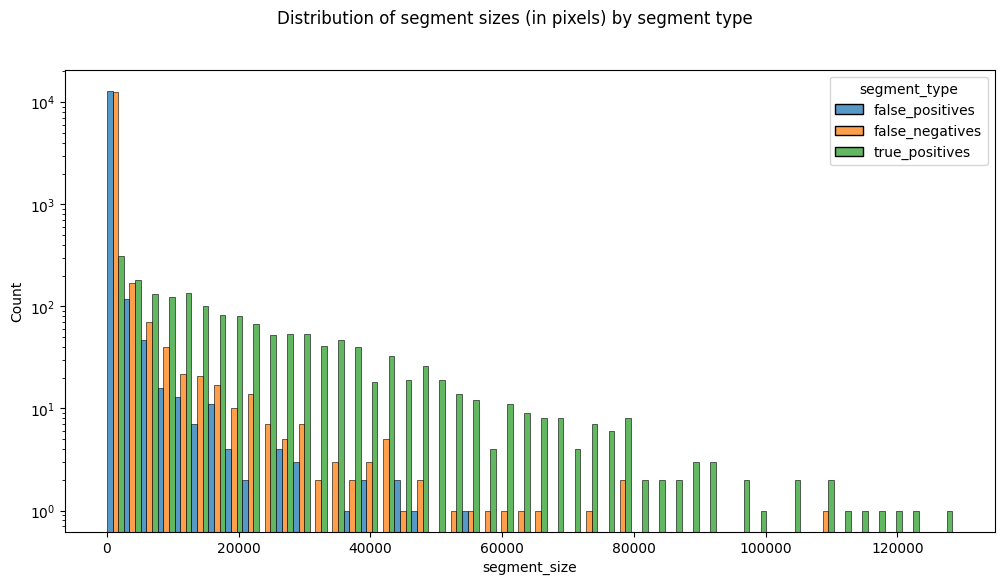

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    bins=50,
    multiple="dodge",
    data=segment_stats,
    x="segment_size",
    hue="segment_type",
    ax=ax,
)
fig.suptitle("Distribution of segment sizes (in pixels) by segment type")
plt.yscale("log")


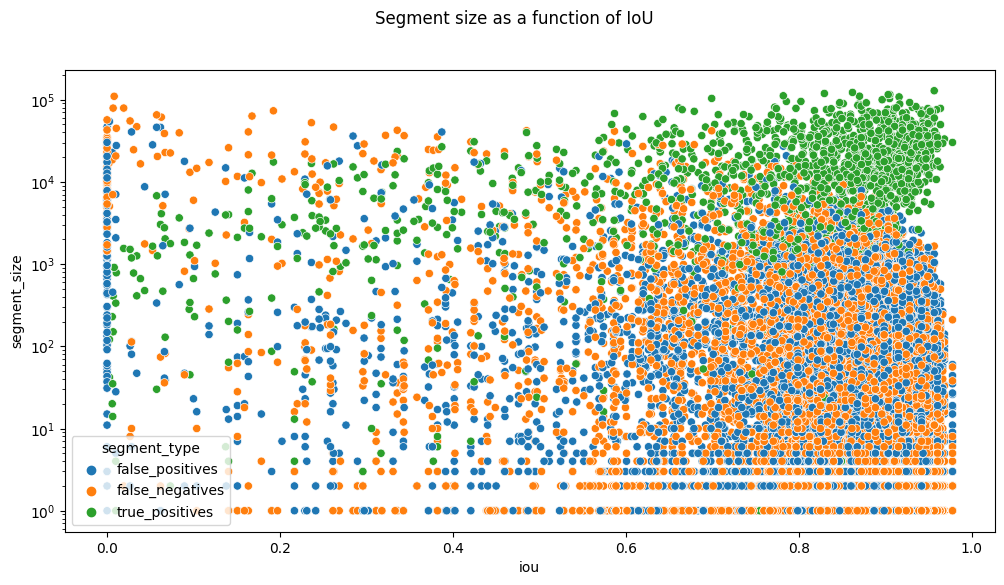

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=segment_stats, x="iou", y="segment_size", hue="segment_type", ax=ax
)
fig.suptitle("Segment size as a function of IoU")
plt.yscale("log")


# For each image, merge all positive clicks together

Positive clicks for TP were generated separately from positive clicks for FN (different criteria).

Now we will use the clicks to train models, and the distinction is not necessary anymore: all positive clicks can be stored together.

In [20]:
builtins.guide_clicks = {}
with open(baseline_dir + "/guide_clicks.json", "r") as gcfile:
    guide_clicks_split = json.load(gcfile)
    for k, v in guide_clicks_split.items():
        v["clicks_positive"] += v["clicks_positive_tp"]
        _ = v.pop("clicks_positive_tp", None)
        builtins.guide_clicks[int(k)] = v

i = 0
for k, v in builtins.guide_clicks.items():
    i += 1
    print(k, v)
    if i > 5:
        break


0 {'clicks_negative': [[193, 178]], 'clicks_positive': [[239, 223], [230, 344], [185, 399], [169, 272]]}
1 {'clicks_negative': [[224, 188], [259, 201], [252, 500], [293, 483]], 'clicks_positive': [[118, 391], [110, 322], [229, 390], [177, 228]]}
2 {'clicks_negative': [[188, 253]], 'clicks_positive': [[290, 320], [340, 271], [224, 298], [277, 266]]}
3 {'clicks_negative': [], 'clicks_positive': []}
4 {'clicks_negative': [], 'clicks_positive': []}
5 {'clicks_negative': [], 'clicks_positive': [[228, 395], [225, 328], [170, 270], [138, 332]]}


# Check image transform functions (augmentations) with clicks applied

Generate a few toy datasets, display them, delete them after that.

Train images and labels have geometric transforms applied.

Test images and labels do not have geometric transforms applied.

Clicks should be visible, where any were generated.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


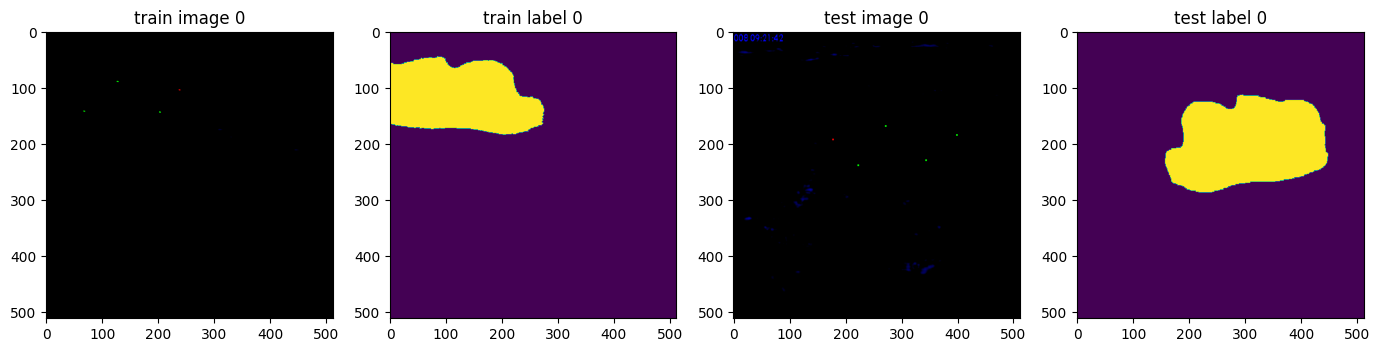

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


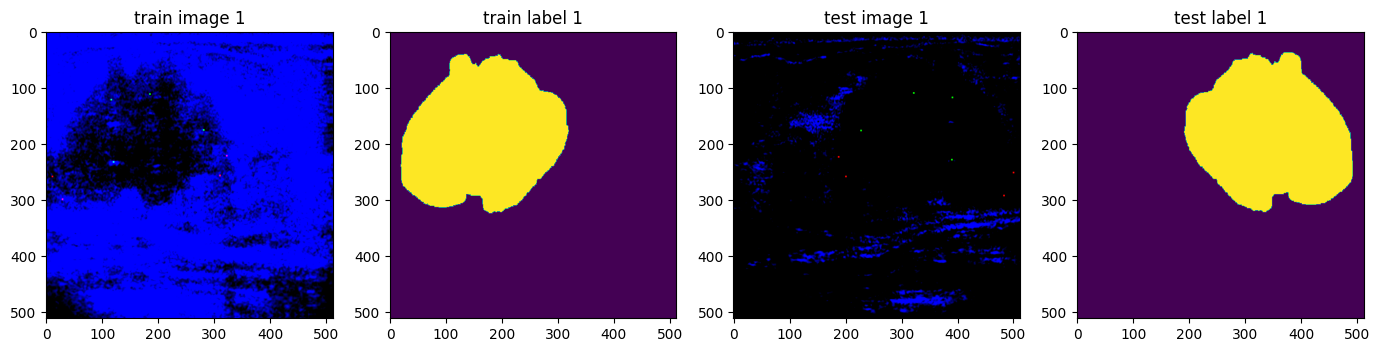

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


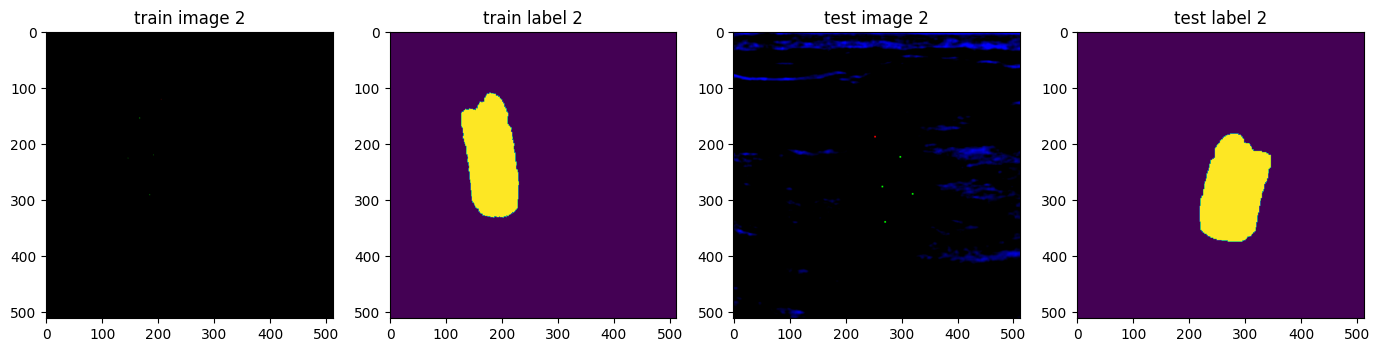

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


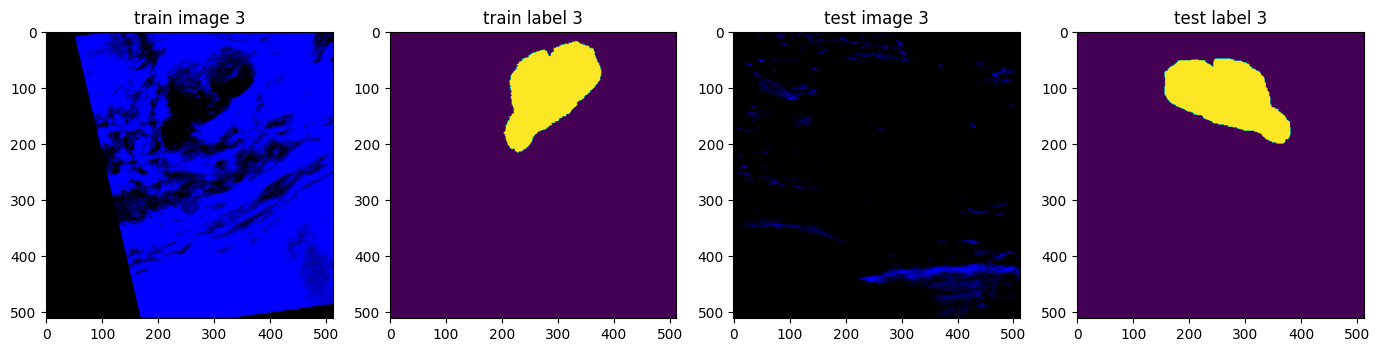

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


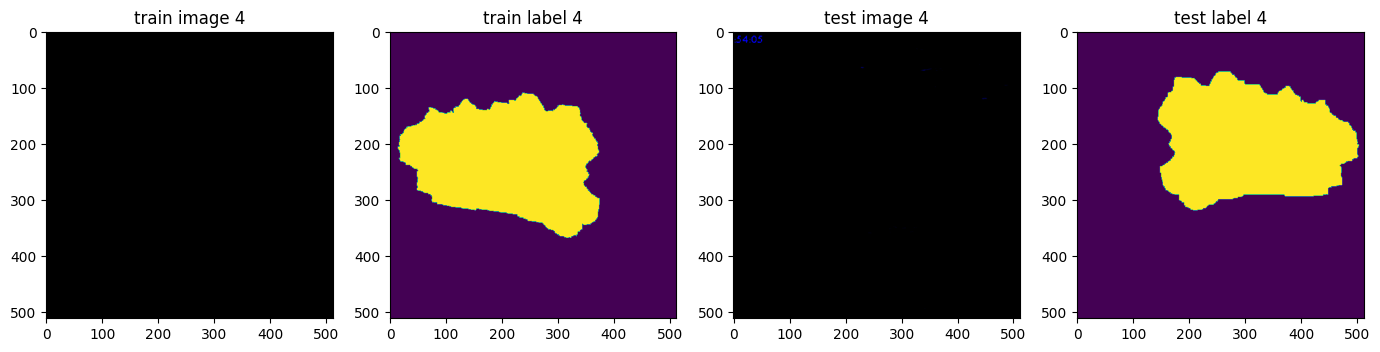

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


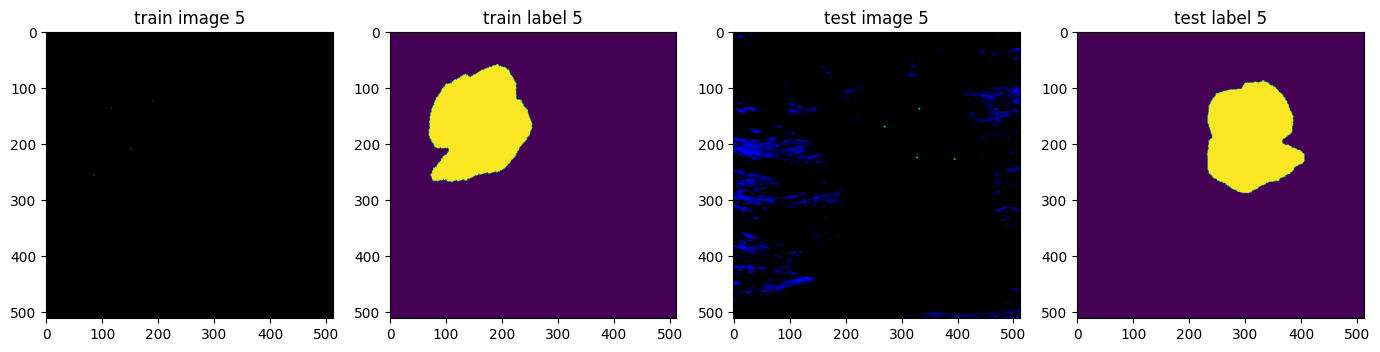

In [21]:
train_index = list(range(6))
test_index = train_index

builtins.APPLY_CLICKS_TRAIN_DS = True
train_ds = ds_hf.select(train_index)
train_ds.set_transform(train_transforms)

# the model only accepts certain columns in the test_ds while training
# so we create two test_ds datasets
# this is for the model training, only has image and label
test_ds = ds_hf.select(test_index)
# this is for generating predictions with a trained model, and has all image attributes
test_ds_check = ds_hf.select(test_index)

builtins.APPLY_CLICKS_TEST_DS = True
test_ds.set_transform(val_transforms)
test_ds_check.set_transform(val_transforms_check)

for i in train_index:
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 8))
    train_item = train_ds[i]
    test_item = test_ds[i]
    ax[0].imshow(np.moveaxis(train_item["pixel_values"], 0, -1))
    ax[0].set_title("train image " + str(i))
    ax[1].imshow(train_item["labels"])
    ax[1].set_title("train label " + str(i))
    ax[2].imshow(np.moveaxis(test_item["pixel_values"], 0, -1))
    ax[2].set_title("test image " + str(i))
    ax[3].imshow(test_item["labels"])
    ax[3].set_title("test label " + str(i))
    plt.show()

del train_ds
del test_ds
del test_ds_check


# Train models with clicks

Using clicks inferred from the baseline model predictions, train new models to respond to clicks.

Same as the baseline models: 5-fold split, generate 5 separate models, save predictions and performance metrics.

Predictions will be generated with clicks, and without clicks. Prediction without clicks should be similar to the baseline models.

In [22]:
clicktrained_dir = "model_clicktrained_" + model_name

model_dir_clicks = clicktrained_dir + "/models"
output_dir_clicks = clicktrained_dir + "/outputs"
logging_dir_clicks = clicktrained_dir + "/logs"
folds_dir_clicks = clicktrained_dir + "/folds"

os.makedirs(model_dir_clicks, exist_ok=True)
os.makedirs(logging_dir_clicks, exist_ok=True)
os.makedirs(folds_dir_clicks, exist_ok=True)

predictions_path = clicktrained_dir + "/predictions"

test_cases = {
    "train clicks only": {
        "path_suffix": "_clicks_train",
        "apply_clicks_test_ds": False,
        "performance_metrics": {},
        "run_test_case": False,
    },
    "train and test clicks": {
        "path_suffix": "_clicks_train_test",
        "apply_clicks_test_ds": True,
        "performance_metrics": {},
        "run_test_case": False,
    },
}
for tc_name in test_cases.keys():
    if not os.path.exists(
        predictions_path
        + test_cases[tc_name]["path_suffix"]
        + "/performance_metrics.json"
    ):
        # if this specific performance_metrics.json does not exist, run this test case
        test_cases[tc_name]["run_test_case"] = True

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
fold = 0
performance_metrics_clicks = {}
fold_metrics_training_clicks = {}

for train_index, test_index in skf.split(
    train_df.index.to_list(), train_df["dataset_tumor"]
):
    # shuffle the train order to mix all datasets together
    # test order doesn't matter
    rng = np.random.default_rng(seed=1)
    rng.shuffle(train_index)

    fold += 1
    print("\n###################################################")
    print(f"fold {fold}")

    if not os.path.exists(model_dir_clicks + "/fold-" + str(fold).zfill(10)):
        print("model does not exist, train it")

        builtins.APPLY_CLICKS_TRAIN_DS = True
        train_ds = ds_hf.select(train_index)
        train_ds.set_transform(train_transforms)

        # the model only accepts certain columns in the test_ds while training
        # so we create two test_ds datasets
        # this is for training, only has image and label
        test_ds = ds_hf.select(test_index)
        # this is for testing, and has all image attributes
        test_ds_check = ds_hf.select(test_index)

        builtins.APPLY_CLICKS_TEST_DS = True
        test_ds.set_transform(val_transforms)
        test_ds_check.set_transform(val_transforms_check)

        fold_metrics_training_clicks[fold] = objective(
            fold=fold,
            train_ds=train_ds,
            test_ds=test_ds,
            model_dir=model_dir_clicks,
            logging_dir=logging_dir_clicks,
            output_dir=output_dir_clicks,
            folds_dir=folds_dir_clicks,
            epochs=num_epochs,
        )
        print()
        print(
            "mean performance per fold, from total pixel counts across the entire fold, measured during training:"
        )
        print(pd.DataFrame(fold_metrics_training_clicks[fold], index=["values"]).T)
    else:
        print("model exists, do not train it")

    for test_case_name in test_cases.keys():
        print()
        print(f"test case: {test_case_name}")
        if test_cases[tc_name]["run_test_case"]:
            pr_path = predictions_path + test_cases[test_case_name]["path_suffix"]
            print(f"load trained model to evaluate performance")
            best_model_dir_clicks = model_dir_clicks + "/fold-" + str(fold).zfill(10)
            logging.set_verbosity(50)
            model = SegformerForSemanticSegmentation.from_pretrained(
                best_model_dir_clicks,
                id2label=id2label,
                label2id=label2id,
                num_labels=num_labels,
            )
            model.to("cuda:0")
            logging.set_verbosity(40)

            test_ds_check = ds_hf.select(test_index)
            builtins.APPLY_CLICKS_TEST_DS = test_cases[test_case_name][
                "apply_clicks_test_ds"
            ]
            test_ds_check.set_transform(val_transforms_check)

            performance_metrics_fold = generate_predictions(
                model=model, test_ds=test_ds_check, pr_path=pr_path
            )
            for k, v in performance_metrics_fold.items():
                test_cases[test_case_name]["performance_metrics"][k] = v

            del model
            torch.cuda.empty_cache()
        else:
            print("test case has been measured already, skip it")

for test_case_name in test_cases.keys():
    if test_cases[tc_name]["run_test_case"]:
        with open(
            predictions_path
            + test_cases[test_case_name]["path_suffix"]
            + "/performance_metrics.json",
            "w",
        ) as pfile:
            json.dump(
                test_cases[test_case_name]["performance_metrics"], pfile, indent=2
            )

if len(fold_metrics_training_clicks.keys()) == 5:
    with open(clicktrained_dir + "/fold_metrics_training_clicks.json", "w") as pfile:
        json.dump(fold_metrics_training_clicks, pfile, indent=2)



###################################################
fold 1
model does not exist, train it

mean performance per fold, from total pixel counts across the entire fold, measured during training:
                     values
best_iou           0.897830
best_dice          0.946165
best_precision     0.948610
best_recall        0.943732
best_step       9720.000000
best_loss          0.022460

test case: train clicks only
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/359 [00:00<?, ?it/s]

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_positives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277: RuntimeWarning: invalid value encountered in divide
  niou = total_true_positives / (
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:281: RuntimeWarning: invalid value encountered in divide
  2
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_a


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.815144
iou        0.750569
precision  0.855800
recall     0.810945

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.864050
iou        0.760641
precision  0.920442
recall     0.814169

test case: train and test clicks
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/359 [00:00<?, ?it/s]

...

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_positives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_area_label
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:287: RuntimeWarning: invalid value encountered in divide
  recall = total_true_positives / (total_true_positives + total_false_negatives)
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277:


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.847358
iou        0.783484
precision  0.883724
recall     0.848098

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.868048
iou        0.766859
precision  0.908130
recall     0.831355

test case: train and test clicks
load trained model to evaluate performance
generate predictions, calculate performance


  0%|          | 0/358 [00:00<?, ?it/s]

/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:277: RuntimeWarning: invalid value encountered in divide
  niou = total_true_positives / (
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:281: RuntimeWarning: invalid value encountered in divide
  2
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:285: RuntimeWarning: invalid value encountered in divide
  acc = total_true_positives / total_area_label
/home/florin/.cache/huggingface/modules/evaluate_modules/metrics/mean_dice/1560c0110ad4341bb1ed93549414662833eab93a30c2e608a3cc97f29a18656e/mean_dice.py:286: RuntimeWarning: invalid value encountered in divide
  precision = total_true_positives / (total_true_positives + total_false_p


performance frame by frame, averaged by fold, measured with trained model:
             values
dice       0.935337
iou        0.884748
precision  0.942173
recall     0.933719

mean performance per fold, from total pixel counts across the entire fold, measured with trained model
             values
dice       0.944763
iou        0.895309
precision  0.950975
recall     0.938632


# Extract all performance metrics for each image, for each model

For the click-trained models, get performance metrics when testing with and without clicks.

In [23]:
test_cases["baseline model"] = {}

for test_case_name in test_cases.keys():
    if test_case_name != "baseline model":
        with open(
            predictions_path
            + test_cases[test_case_name]["path_suffix"]
            + "/performance_metrics.json",
            "r",
        ) as pfile:
            pm_temp = json.load(pfile)
            test_cases[test_case_name]["performance_metrics"] = {
                int(k): v for k, v in pm_temp.items()
            }
    else:
        with open(
            baseline_dir + "/predictions.json",
            "r",
        ) as pfile:
            pm_temp = json.load(pfile)
            test_cases[test_case_name]["performance_metrics"] = {
                int(k): v for k, v in pm_temp.items()
            }

    test_cases[test_case_name]["image_perf_df"] = train_df[
        ["dataset", "tumor", "dataset_tumor"]
    ].copy()
    test_cases[test_case_name]["image_perf_df"]["iou"] = [
        test_cases[test_case_name]["performance_metrics"][x]["per_category_niou"][1]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    test_cases[test_case_name]["image_perf_df"]["dice"] = [
        test_cases[test_case_name]["performance_metrics"][x]["per_category_dice"][1]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    test_cases[test_case_name]["image_perf_df"]["precision"] = [
        test_cases[test_case_name]["performance_metrics"][x]["per_category_precision"][
            1
        ]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    test_cases[test_case_name]["image_perf_df"]["recall"] = [
        test_cases[test_case_name]["performance_metrics"][x]["per_category_recall"][1]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    test_cases[test_case_name]["image_perf_df"]["area_label"] = [
        test_cases[test_case_name]["performance_metrics"][x]["total_area_label"][1]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    test_cases[test_case_name]["image_perf_df"]["area_pred"] = [
        test_cases[test_case_name]["performance_metrics"][x]["total_area_pred"][1]
        for x in range(len(test_cases[test_case_name]["performance_metrics"].keys()))
    ]
    print(test_case_name)
    display(test_cases[test_case_name]["image_perf_df"].head(5))


train clicks only


,dataset,tumor,dataset_tumor,iou,dice,precision,recall,area_label,area_pred
0,BUSIS,benign,BUSIS_benign,0.912630,0.954319,0.918290,0.993292,38310.0,41439.0
1,BUSIS,malignant,BUSIS_malignant,0.899502,0.947092,0.910994,0.986170,60954.0,65984.0
2,BUSIS,malignant,BUSIS_malignant,0.824243,0.903655,0.926690,0.881738,17791.0,16928.0
3,BUSIS,benign,BUSIS_benign,0.909653,0.952690,0.990436,0.917715,20988.0,19447.0
4,BUSIS,malignant,BUSIS_malignant,0.930848,0.964186,0.979411,0.949427,62780.0,60858.0


train and test clicks


,dataset,tumor,dataset_tumor,iou,dice,precision,recall,area_label,area_pred
0,BUSIS,benign,BUSIS_benign,0.936198,0.967048,0.952481,0.982067,38310.0,39500.0
1,BUSIS,malignant,BUSIS_malignant,0.943241,0.970792,0.964791,0.976868,60954.0,61717.0
2,BUSIS,malignant,BUSIS_malignant,0.885755,0.939417,0.945001,0.933899,17791.0,17582.0
3,BUSIS,benign,BUSIS_benign,0.909653,0.952690,0.990436,0.917715,20988.0,19447.0
4,BUSIS,malignant,BUSIS_malignant,0.930848,0.964186,0.979411,0.949427,62780.0,60858.0


baseline model


,dataset,tumor,dataset_tumor,iou,dice,precision,recall,area_label,area_pred
0,BUSIS,benign,BUSIS_benign,0.934169,0.965964,0.944324,0.988619,38310.0,40107.0
1,BUSIS,malignant,BUSIS_malignant,0.874360,0.932969,0.882431,0.989648,60954.0,68360.0
2,BUSIS,malignant,BUSIS_malignant,0.818906,0.900438,0.893830,0.907144,17791.0,18056.0
3,BUSIS,benign,BUSIS_benign,0.940002,0.969073,0.987825,0.951020,20988.0,20206.0
4,BUSIS,malignant,BUSIS_malignant,0.921937,0.959383,0.956739,0.962042,62780.0,63128.0


Average IoU over all images, for:

- click-trained model, tested without clicks
- click-trained model, tested with clicks
- baseline model

In [24]:
print(f"mean frame IoU all datasets:")
print()
for test_case_name in test_cases.keys():
    print(
        f"{test_case_name.ljust(25, ' ')}{test_cases[test_case_name]['image_perf_df']['iou'].mean()}"
    )


mean frame IoU all datasets:

train clicks only        0.773831092225366
train and test clicks    0.884469390624299
baseline model           0.7657448928870212


In [25]:
dataset_mean_iou_clicks = pd.DataFrame(data={}, columns=["dataset", "iou", "test_case"])
dataset_mean_dice_clicks = pd.DataFrame(
    data={}, columns=["dataset", "dice", "test_case"]
)
for test_case_name in test_cases.keys():
    ds_temp = pd.DataFrame(
        test_cases[test_case_name]["image_perf_df"].groupby(["dataset"])["iou"].mean()
    ).reset_index()
    ds_temp["test_case"] = [test_case_name] * len(ds_temp.index.to_list())
    dataset_mean_iou_clicks = pd.concat([dataset_mean_iou_clicks, ds_temp])
    ds_temp = pd.DataFrame(
        test_cases[test_case_name]["image_perf_df"].groupby(["dataset"])["dice"].mean()
    ).reset_index()
    ds_temp["test_case"] = [test_case_name] * len(ds_temp.index.to_list())
    dataset_mean_dice_clicks = pd.concat([dataset_mean_dice_clicks, ds_temp])


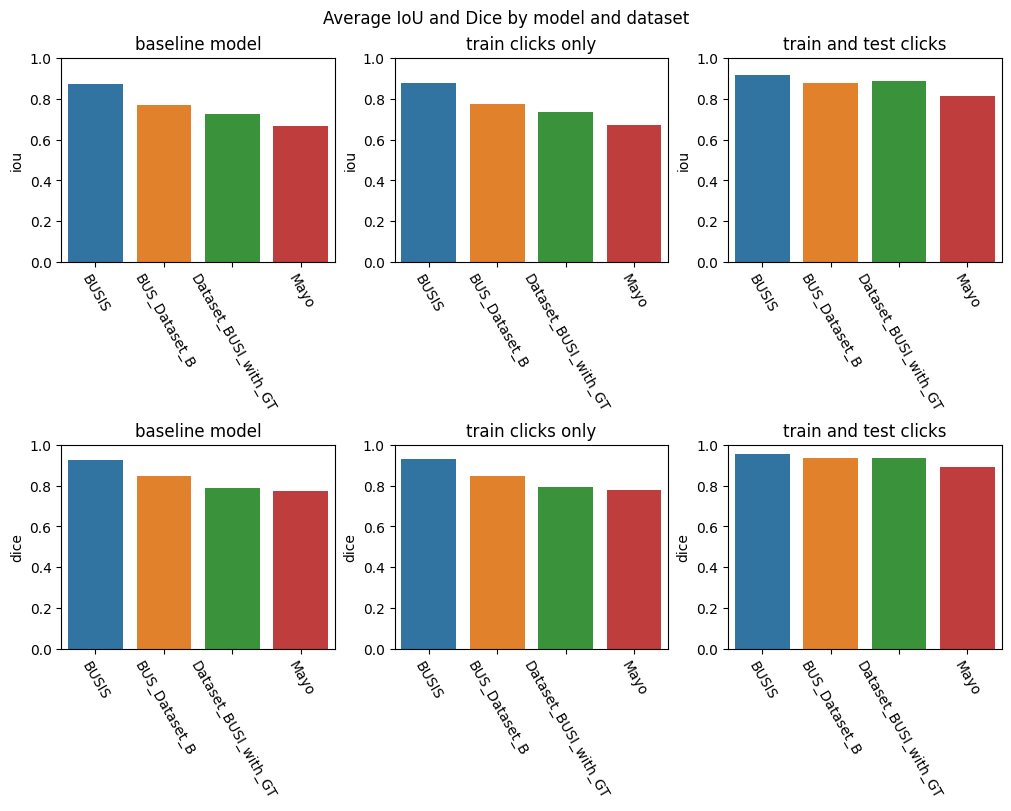

In [26]:
title = ["baseline model", "train clicks only", "train and test clicks"]
ds = {
    0: {
        "y": "iou",
        "df": dataset_mean_iou_clicks,
    },
    1: {
        "y": "dice",
        "df": dataset_mean_dice_clicks,
    },
}
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 8), constrained_layout=True)
for d in range(2):
    for r in range(3):
        ax[d, r].set_ylim([0, 1])
        sns.barplot(
            data=ds[d]["df"].query(f"test_case == '{title[r]}'"),
            hue=ds[d]["df"].query(f"test_case == '{title[r]}'")["dataset"].to_list(),
            x="dataset",
            y=ds[d]["y"],
            ax=ax[d, r],
            dodge=False,
        )
        ax[d, r].set_title(title[r])
        ax[d, r].legend().set_visible(False)
        ax[d, r].tick_params(axis="x", labelrotation=-60)
        ax[d, r].set(xlabel=None)
plt.suptitle("Average IoU and Dice by model and dataset")
plt.show()


/tmp/ipykernel_9202/3824740722.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


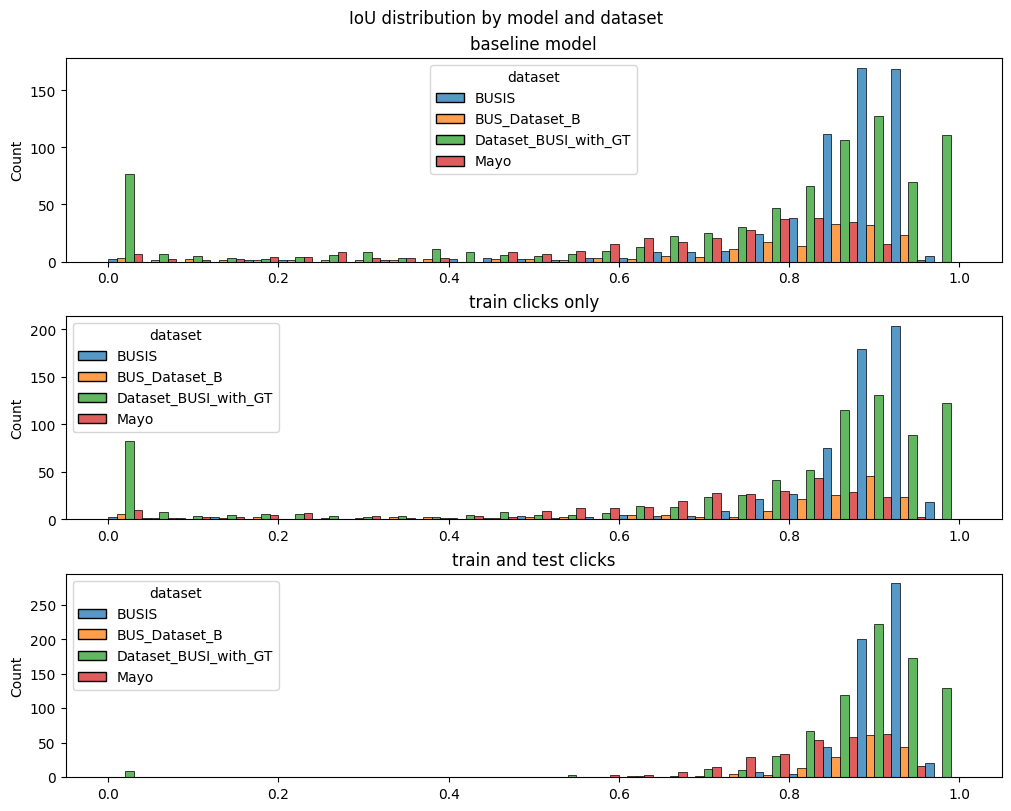

In [27]:
fig, ax = plt.subplots(
    nrows=len(title), ncols=1, figsize=(10, 8), constrained_layout=True
)
for t in range(len(title)):
    sns.histplot(
        data=test_cases[title[t]]["image_perf_df"],
        x="iou",
        hue="dataset",
        ax=ax[t],
        bins=25,
        multiple="dodge",
    )
    ax[t].set_title(title[t])
    ax[t].set(xlabel=None)
fig.suptitle("IoU distribution by model and dataset")
fig.show()


/tmp/ipykernel_9202/3192106272.py:15: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


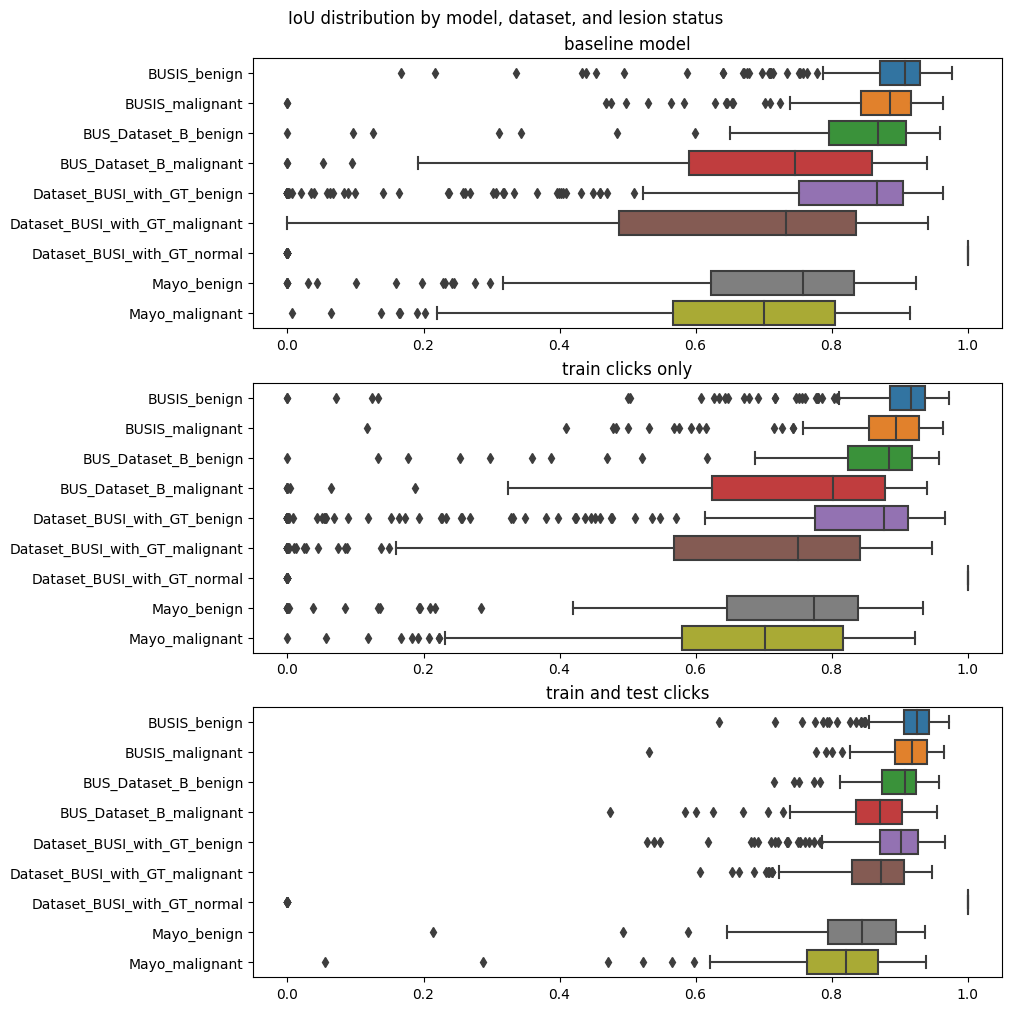

In [28]:
fig, ax = plt.subplots(
    nrows=len(title), ncols=1, figsize=(10, 10), constrained_layout=True
)
for t in range(len(title)):
    sns.boxplot(
        data=test_cases[title[t]]["image_perf_df"],
        x="iou",
        y="dataset_tumor",
        orient="h",
        ax=ax[t],
    )
    ax[t].set_title(title[t])
    ax[t].set(xlabel=None, ylabel=None)
fig.suptitle("IoU distribution by model, dataset, and lesion status")
fig.show()


# Final frames

For each image, generate a big frame containing:

- the original image
- the ground-truth label (mask)
- prediction from baseline model
- prediction from click-trained model, with clicks provided during prediction
- prediction from click-trained model, without clicks provided during prediction

In [29]:
final_frames_path = "final_frames_" + model_name
ims = builtins.image_size[0]

if not os.path.exists(final_frames_path):
    os.makedirs(final_frames_path, exist_ok=True)
    for i in tqdm(range(len(ds_hf))):
        image_info = image_perf_df.loc[i, :]
        image_index = ds_hf[i]["index"]

        original_image = ds_hf[i]["original_image"]

        label_arr = np.array(ds_hf[i]["label"], dtype=np.uint8) * 255
        label_img = ImageOps.colorize(
            Image.fromarray(label_arr, mode="L"),
            black=[0, 0, 0],
            white=[255, 255, 0],
            blackpoint=0,
            whitepoint=255,
        )

        pred_baseline_arr = (
            np.array(
                Image.open(baseline_dir + "/predictions/" + str(image_index) + ".png"),
                dtype=np.uint8,
            )
            * 255
        )
        pred_baseline_img = ImageOps.colorize(
            Image.fromarray(pred_baseline_arr, mode="L"),
            black=[0, 0, 0],
            white=[255, 255, 0],
            blackpoint=0,
            whitepoint=255,
        )

        pred_train_test_click_arr = (
            np.array(
                Image.open(
                    predictions_path
                    + test_cases["train and test clicks"]["path_suffix"]
                    + "/"
                    + str(image_index)
                    + ".png"
                ),
                dtype=np.uint8,
            )
            * 255
        )
        pred_train_test_click_img = ImageOps.colorize(
            Image.fromarray(pred_train_test_click_arr, mode="L"),
            black=[0, 0, 0],
            white=[255, 255, 0],
            blackpoint=0,
            whitepoint=255,
        )

        pred_train_click_arr = (
            np.array(
                Image.open(
                    predictions_path
                    + test_cases["train clicks only"]["path_suffix"]
                    + "/"
                    + str(image_index)
                    + ".png"
                ),
                dtype=np.uint8,
            )
            * 255
        )
        pred_train_click_img = ImageOps.colorize(
            Image.fromarray(pred_train_click_arr, mode="L"),
            black=[0, 0, 0],
            white=[255, 255, 0],
            blackpoint=0,
            whitepoint=255,
        )

        img_label_merged = Image.composite(
            label_img, original_image, Image.fromarray(label_arr, mode="L")
        )
        pred_baseline_merged = Image.composite(
            pred_baseline_img,
            original_image,
            Image.fromarray(pred_baseline_arr, mode="L"),
        )
        pred_train_test_click_merged = Image.composite(
            pred_train_test_click_img,
            original_image,
            Image.fromarray(pred_train_test_click_arr, mode="L"),
        )
        pred_train_click_merged = Image.composite(
            pred_train_click_img,
            original_image,
            Image.fromarray(pred_train_click_arr, mode="L"),
        )

        oi_text = (
            "original image\ndataset: "
            + image_info["dataset"]
            + "\nlesion class: "
            + image_info["tumor"]
            + "\nimage index: "
            + str(i)
        )
        draw = ImageDraw.Draw(original_image)
        bbox = draw.multiline_textbbox((0, 0), oi_text)
        draw.rectangle(bbox, fill="black")
        draw.text((0, 0), oi_text)

        label_text = "ground truth label"
        draw = ImageDraw.Draw(img_label_merged)
        bbox = draw.multiline_textbbox((0, 0), label_text)
        draw.rectangle(bbox, fill="black")
        draw.text((0, 0), label_text)

        pred_baseline_text = "prediction from plain model\nIoU: " + str(
            round(image_info["iou"], ndigits=4)
        )
        draw = ImageDraw.Draw(pred_baseline_merged)
        bbox = draw.multiline_textbbox((0, 0), pred_baseline_text)
        draw.rectangle(bbox, fill="black")
        draw.text((0, 0), pred_baseline_text)

        pred_train_test_click_text = (
            "prediction from model trained and tested with clicks\nIoU: "
            + str(
                round(
                    test_cases["train and test clicks"]["image_perf_df"].loc[i, "iou"],
                    ndigits=4,
                )
            )
        )
        draw = ImageDraw.Draw(pred_train_test_click_merged)
        bbox = draw.multiline_textbbox((0, 0), pred_train_test_click_text)
        draw.rectangle(bbox, fill="black")
        draw.text((0, 0), pred_train_test_click_text)

        pred_train_click_text = (
            "prediction from model trained with clicks\nIoU: "
            + str(
                round(
                    test_cases["train clicks only"]["image_perf_df"].loc[i, "iou"],
                    ndigits=4,
                )
            )
        )
        draw = ImageDraw.Draw(pred_train_click_merged)
        bbox = draw.multiline_textbbox((0, 0), pred_train_click_text)
        draw.rectangle(bbox, fill="black")
        draw.text((0, 0), pred_train_click_text)

        if len(guide_clicks[i]["clicks_positive"]) > 0:
            for c in guide_clicks[i]["clicks_positive"]:
                # Pillow and Numpy disagree on the meaning of X and Y
                # we use the Numpy convention
                # so for Pillow we swap X and Y
                ImageDraw.Draw(pred_train_test_click_merged).rectangle(
                    xy=[(c[1] - 1, c[0] - 1), (c[1] + 1, c[0] + 1)],
                    outline=(0, 255, 0),
                    fill=(0, 255, 0),
                    width=1,
                )

        if len(guide_clicks[i]["clicks_negative"]) > 0:
            for c in guide_clicks[i]["clicks_negative"]:
                ImageDraw.Draw(pred_train_test_click_merged).rectangle(
                    xy=[(c[1] - 1, c[0] - 1), (c[1] + 1, c[0] + 1)],
                    outline=(255, 0, 0),
                    fill=(255, 0, 0),
                    width=1,
                )

        big_frame = Image.new(mode="RGB", size=(ims * 3, ims * 2), color=(0, 0, 0))
        big_frame.paste(original_image, box=(0, 0))
        big_frame.paste(img_label_merged, box=(ims, 0))
        big_frame.paste(pred_baseline_merged, box=(0, ims))
        big_frame.paste(pred_train_test_click_merged, box=(ims, ims))
        big_frame.paste(pred_train_click_merged, box=(ims * 2, ims))
        big_frame.save(final_frames_path + "/" + str(image_index).zfill(4) + ".png")
else:
    print(f"Folder {final_frames_path} exists. Skip.")


  0%|          | 0/1794 [00:00<?, ?it/s]

In [30]:
! bash ./notify.sh
